### **Remote Path**

In [1]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')

### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image

from tools.spikegen_tools import get_instantaneous_activity

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch



### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [ ]:
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 6 Dynapse1DevKit serial_number 00000033
Selected device: 00000033
Sender port: tcp://0.0.0.0:46783
Receiver port: tcp://0.0.0.0:43527
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


### Initialize Dynap-SE

In [43]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters


config1     = model.get_configuration() 

param_group0 = config1.chips[0].cores[0].parameter_group 
param_group1 = config1.chips[0].cores[1].parameter_group 
param_group2 = config1.chips[0].cores[2].parameter_group 
param_group3 = config1.chips[0].cores[3].parameter_group 

### **Set Neuron/Dendrite Parameters**

In [44]:
"""Populations on Core : S, I"""

# set AMPA (fast excitatory) weight 
param_group0.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group0.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group0.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 90    
param_group0.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group0.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_F_N'].fine_value =  70      
param_group0.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5


# set AMPA (fast exc) tau 
param_group0.param_map['NPDPIE_TAU_F_P'].fine_value   = 30      # 50
param_group0.param_map['NPDPIE_TAU_F_P'].coarse_value = 2

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group0.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group0.param_map['NPDPIE_TAU_S_P'].coarse_value = 5

# set GABA A (fast inhibitory) tau                              
param_group0.param_map['NPDPII_TAU_F_P'].fine_value = 40
param_group0.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group0.param_map['NPDPII_TAU_S_P'].fine_value = 35
param_group0.param_map['NPDPII_TAU_S_P'].coarse_value = 4


# Neuron membrane voltage gain
param_group0.param_map['IF_THR_N'].fine_value = 100
param_group0.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group0.param_map['IF_RFR_N'].fine_value = 40
param_group0.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group0.param_map['IF_DC_P'].fine_value = 20
param_group0.param_map['IF_DC_P'].coarse_value = 0



In [45]:
"""Populations on Core : SpikeGens"""

# set AMPA (fast excitatory) weight 
param_group1.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 120     #100
param_group1.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group1.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70nottoday
param_group1.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group1.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group1.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group1.param_map['NPDPIE_TAU_F_P'].fine_value   = 40    #30
param_group1.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group1.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group1.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group1.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group1.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group1.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group1.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group1.param_map['IF_THR_N'].fine_value = 100
param_group1.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group1.param_map['IF_RFR_N'].fine_value = 80
param_group1.param_map['IF_RFR_N'].coarse_value = 2

# Bias Current 
param_group1.param_map['IF_DC_P'].fine_value = 0
param_group1.param_map['IF_DC_P'].coarse_value = 0


In [46]:
"""Populations on Core : T """

# set AMPA (fast excitatory) weight 
param_group2.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 150
param_group2.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group2.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group2.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group2.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group2.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group2.param_map['NPDPIE_TAU_F_P'].fine_value   = 30   #20
param_group2.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group2.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group2.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group2.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group2.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group2.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group2.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group2.param_map['IF_THR_N'].fine_value = 50
param_group2.param_map['IF_THR_N'].coarse_value = 4

# Refactory period (Base 4, 128?)
#param_group2.param_map['IF_RFR_N'].fine_value = 10
#param_group2.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group2.param_map['IF_DC_P'].fine_value = 0
param_group2.param_map['IF_DC_P'].coarse_value = 0


In [47]:
"""Populations on Core : IIT, IIT, Sum"""

# set AMPA (fast excitatory) weight 
param_group3.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 100    #max90
param_group3.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group3.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70
param_group3.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100       #max120
param_group3.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group3.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group3.param_map['NPDPIE_TAU_F_P'].fine_value   = 30         #max10
param_group3.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group3.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group3.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group3.param_map['NPDPII_TAU_F_P'].fine_value = 60           #max20
param_group3.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group3.param_map['NPDPII_TAU_S_P'].fine_value = 20         #max50
param_group3.param_map['NPDPII_TAU_S_P'].coarse_value = 4       #max3



# Neuron membrane voltage gain
#param_group3.param_map['IF_THR_N'].fine_value = 90
#param_group3.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group3.param_map['IF_RFR_N'].fine_value = 60
param_group3.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current 
param_group3.param_map['IF_DC_P'].fine_value = 50
param_group3.param_map['IF_DC_P'].coarse_value = 0




In [48]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))

# Voltage gain

print("\n--- Membrane Voltage gain ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_THR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_THR_N'].fine_value))

# refactory period

print("\n--- Refractory period ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].fine_value))



--- AMPA (fast excitatory) weight ---
Linear: 17254902.0
Coarse: 5
Fine: 110

--- NMDA (slow excitatory) weight ---
Linear: 14117648.0
Coarse: 5
Fine: 90

--- GABA B (slow inhibitory) weight ---
Linear: 15686275.0
Coarse: 5
Fine: 100

--- GABA A (fast inhibitory) weight ---
Linear: 10980392.0
Coarse: 5
Fine: 70

--- NMDA tau (slow excitatory) ---
Linear: 10980392.0
Coarse: 5
Fine: 70

--- AMPA tau (fast excitatory) ---
Linear: 9676.0
Coarse: 2
Fine: 30

--- Membrane Voltage gain ---
Coarse: 5
Fine: 100

--- Refractory period ---
Coarse: 3
Fine: 40


### **Set Network Parameters**

In [49]:
model.update_parameter_group(param_group0, 0, 0)
model.update_parameter_group(param_group1, 0, 1)
model.update_parameter_group(param_group2, 0, 2)
model.update_parameter_group(param_group3, 0, 3)


NE    = 16        # neurons per excitatory state population
NI    = 12         # inhibitory population size
NSum  = 8         # summation population size
NT    = 8         # transition population size
NIT   = 8         # transition inhibiting population size
NIIT  = 8         # transition inhibiting-inhibiting population size

NS = 3            # number of states
NG = 3            # number of spike generators

exclude_n_ids = [(0,0,5), (0,0,6), (0,0,11), (0,0,15), (0,0,17), (0,0,128),(0,0,129),(0,0,136),(0,0,159), (0,0,242), (0,0,247),
                 (0,1,6),(0,1,60),(0,1,71),(0,1,119),(0,1,223),
                 (0,2,29),(0,2,65),(0,2,60),(0,2,102),(0,2,99),(0,2,172),(0,2,206),
                 (0,3,9),(0,3,64),(0,3,86),(0,3,143),(0,3,183),(0,3,188),(0,3,214),(0,3,239)]

seed = 0


# ------------------------------------------------------------
# WTA
# ------------------------------------------------------------

p_S_S_base, p_S_S_frac = np.full(NS, 0.7), np.full(NS, 0.1)   # AMPA base prob, NMDA fraction
p_S_S_self             = np.full(NS, 0.7)

p_S_I_base, p_S_I_frac = np.full(NS, 0.5), np.full(NS, 0.0)   # AMPA base prob, NMDA fraction
p_I_S_base, p_I_S_frac = np.full(NS, 0.6), np.full(NS, 0.9)   # GABA_A base prob, GABA_B fraction

p_I_I_base, p_I_I_frac = [0.1], [0.0]                         # GABA_A base prob, GABA_B fraction
p_I_I_self             = [0.0]


# ------------------------------------------------------------
# SUM POP + TRANSITION POP INHIBITORS
# ------------------------------------------------------------

p_S_Sum_base, p_S_Sum_frac     = np.full(NS, 0.8), np.full(NS, 0.0)   # AMPA base prob, NMDA fraction
p_Sum_Sum_base, p_Sum_Sum_frac = [0.2], [0.0]                         # AMPA base prob, NMDA fraction

p_Sum_IT_base, p_Sum_IT_frac   = np.full(NS, 1.0), np.full(NS, 0.0)   # AMPA base prob, NMDA fraction
p_S_IIT_base, p_S_IIT_frac     = np.full(NS, 1.0), np.full(NS, 0.0)   # AMPA base prob, NMDA fraction

p_IT_T_base, p_IT_T_frac       = np.full(NS, 1.0), np.full(NS, 1.0)   # GABA_A base prob, GABA_B fraction #0.8
p_IIT_IT_base, p_IIT_IT_frac   = np.full(NS, 1.0), np.full(NS, 1.0)   # GABA_A base prob, GABA_B fraction


# ------------------------------------------------------------
# TRANSITION POP
# ------------------------------------------------------------

p_T_T_base, p_T_T_frac = np.full(NS, 0), np.full(NS, 0.0)   # AMPA base prob, NMDA fraction
p_T_S_base, p_T_S_frac = np.full(NS, 0.8), np.full(NS, 0)     # AMPA base prob, NMDA fraction


# ------------------------------------------------------------
# SPIKE GENERATOR CONNECTION
# ------------------------------------------------------------

p_G_T = 1     # spike generator to transition population, deterministic


identical_connections    = True   # create exact same connections for S populations
pop_specific_connections = False  # apply population-specific connection probabilities

### Plotting Colors

In [50]:
# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------

colors_S = [
    "#93c5fd",
    "#60a5fa",
    "#1e3a8a",  # dark blue
    "#dbeafe",  # very light blue
    "#0d48c8",


]

colors_T = [
    "#86efac",
    "#16a34a",
    "#14532d",  # dark green    
    "#dcfce7",  # very light green
    "#4ade80",

]

colors_IT = [
    "#d8b4fe",
    "#9333ea",
    "#581c87",  # dark purple
    "#f3e8ff",  # very light purpl
    "#c084fc",
]

colors_IIT = [
    "#fca5a5",
    "#dc2626",
    "#7f1d1d",  # dark red
    "#fee2e2",  # very light red
    "#f87171",

]

color_I   = "#9EA2AC"  # dark grey-blue
color_Sum = "#111827"  # near-black

color_in = "#111827"  # near-black

def get_color(colors, idx):
    return colors[idx % len(colors)]

### **Set Firing Rates**

In [1]:
input_firing_rate = 150
sim_time          = 120

In [2]:
rng     = np.random.default_rng(seed)
net_gen = NetworkGenerator()
net_gen.clear_network()


NameError: name 'np' is not defined

### **Build Network**

#### Network

In [ ]:
def make_population(
    size,
    next_true_nid,
    next_disp_idx,
    chip,             
    core,             
    exclude_n_ids,    
    true_to_disp_idx,
    is_spikegen = False,
):
    exclude_n_ids = set(exclude_n_ids or [])

    pop_ids = []
    nid     = next_true_nid

    while len(pop_ids) < size:

        true_id = (chip, core, nid)

        if true_id not in exclude_n_ids:
            pop_ids.append(true_id)

            true_to_disp_idx[true_id] = next_disp_idx
            next_disp_idx += 1

        nid += 1

    pop = [Neuron(chip_, core_, nid_, is_spikegen) for chip_, core_, nid_ in pop_ids]

    next_true_nid = nid

    return pop, pop_ids, next_true_nid, true_to_disp_idx, next_disp_idx

In [ ]:
S_pops   = []
E_ids    = []
T_pops   = [] 
T_ids    = []
IT_pops  = []
IT_ids   = []
IIT_pops = []
IIT_ids  = []

next_true_nid       = 1                 # index as appears on the dynapse
next_disp_idx       = 0                 # index as displayed on plots
true_to_disp_idx    = {}                # ex. true_to_disp_idx[(0, 0, 1)]) = 0
next_neuron_id      = []

for s in range(NS):

    S_pop, S_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NE,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 0,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )

    S_pops.append(S_pop)
    E_ids.extend(S_ids)

next_neuron_id.append(next_disp_idx)

for s in range(NS):

    T_pop, new_T_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
    size             = NT,
    next_true_nid    = next_true_nid,
    next_disp_idx    = next_disp_idx,
    chip             = 0,
    core             = 2,
    exclude_n_ids    = exclude_n_ids,
    true_to_disp_idx = true_to_disp_idx,
)

    T_pops.append(T_pop)
    T_ids.extend(new_T_ids)

next_neuron_id.append(next_disp_idx)

for s in range(NS):

    IT_pop, new_IT_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NIT,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 3,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )

    IT_pops.append(IT_pop)
    IT_ids.extend(new_IT_ids)

next_neuron_id.append(next_disp_idx)

for s in range(NS):

    IIT_pop, new_IIT_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NIIT,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 3,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )

    IIT_pops.append(IIT_pop)
    IIT_ids.extend(new_IIT_ids)

next_neuron_id.append(next_disp_idx)

I_pop, I_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NI,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 0,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )
next_neuron_id.append(next_disp_idx)

Sum_pop, Sum_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NSum,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 3,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )
next_neuron_id.append(next_disp_idx)



spikegens, spikegen_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NG,
        next_true_nid      = 1,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 1,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
        is_spikegen        = True
    )


#### Connection Matrix

In [ ]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NS * (NE + NT + NIT + NIIT) + NI + NSum  # all real neurons
N_tot = N_hw + NG      # real neurons + spike generators

C = np.zeros((N_tot, N_tot))


def get_idx(n):
    true_id = (0, n.core_id, n.neuron_id)

    return true_to_disp_idx[true_id]


def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

#### Create Connections

In [ ]:

def make_connections(N_pre, N_post, p_base, p_frac, sync_pop_conns=False):
    conns_all = []

    N_tot = N_pre * N_post

    for i in range(len(p_base)):

        n_conn  = int(round(N_tot * p_base[i]))
        n_type2 = int(round(n_conn * p_frac[i]))
        n_type1 = n_conn - n_type2
        n_zero  = N_tot - n_conn

        conns = np.array(
            [1] * n_type1 +
            [2] * n_type2 +
            [0] * n_zero
        )

        np.random.shuffle(conns)

        conns = conns.reshape(N_post, N_pre)

        conns_all.append(conns)

    if sync_pop_conns:
        conns_all = [conns_all[0].copy() for _ in conns_all]

    return conns_all


def make_square_connections(N, p_base, p_frac, p_self=0.0, sync_pop_conns=False):
    conns_all = []

    n_offdiag_possible = N * N - N

    for i in range(len(p_base)): # TODO

        n_total = int(round(n_offdiag_possible * p_base[i]))
        n_self  = int(round(N * p_self[i]))
        n_self  = min(n_self, N, n_total)
        
        n_offdiag = n_total - n_self

        n_type2 = int(round(n_total * p_frac[i]))
        n_type1 = n_total - n_type2

        conn_values = np.array(
            [1] * n_type1 +
            [2] * n_type2
        )

        np.random.shuffle(conn_values)

        self_values    = conn_values[:n_self]
        offdiag_values = conn_values[n_self:]

        conns = np.zeros((N, N), dtype=int)

        offdiag_mask = ~np.eye(N, dtype=bool)

        offdiag_indices = np.where(offdiag_mask.ravel())[0]
        chosen_offdiag  = np.random.choice(
            offdiag_indices,
            size=n_offdiag,
            replace=False
        )

        conns.ravel()[chosen_offdiag] = offdiag_values

        if n_self > 0:
            diag_indices = np.random.choice(N, size=n_self, replace=False)
            conns[diag_indices, diag_indices] = self_values

        conns_all.append(conns)

    if sync_pop_conns:
        conns_all = [conns_all[0].copy() for _ in conns_all]

    return conns_all

In [ ]:
s_s_conns       = make_square_connections(  NE, p_S_S_base, p_S_S_frac, p_S_S_self, identical_connections)
s_I_conns       = make_connections(         NE, NI, p_S_I_base, p_S_I_frac, identical_connections)
I_s_conns       = make_connections(         NI, NE, p_I_S_base, p_I_S_frac, identical_connections)

I_I_conns       = make_square_connections(NI, p_I_I_base, p_I_I_frac, p_I_I_self, identical_connections)

S_Sum_conns     = make_connections(NE, NSum,  p_S_Sum_base,  p_S_Sum_frac,  identical_connections)
Sum_IT_conns    = make_connections(NSum, NIT, p_Sum_IT_base, p_Sum_IT_frac, identical_connections)
IIT_IT_conns    = make_connections(NIIT, NIT, p_IIT_IT_base, p_IIT_IT_frac, identical_connections)
S_IIT_conns     = make_connections(NE, NIIT,  p_S_IIT_base,  p_S_IIT_frac,  identical_connections)
T_S_conns       = make_connections(NT, NE,    p_T_S_base,    p_T_S_frac,    identical_connections)
IT_T_conns      = make_connections(NIT, NT,   p_IT_T_base,  p_IT_T_frac,    identical_connections)

In [ ]:
def add_conn(src_neuron, tgt_neuron, syn_type):
    
    net_gen.add_connection(src_neuron, tgt_neuron, syn_type)

    src_neuron_idx = get_idx(src_neuron)
    tgt_neuron_idx = get_idx(tgt_neuron)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_neuron_idx, tgt_neuron_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_neuron_idx, tgt_neuron_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_neuron_idx, tgt_neuron_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_neuron_idx, tgt_neuron_idx] = -2

In [ ]:
def add_conns_from_matrix(pre_pop, post_pop, conn_matrix, synapse_map):
    """
    conn_matrix[post_idx, pre_idx]
    """

    post_ids, pre_ids = np.nonzero(conn_matrix)

    for post_idx, pre_idx in zip(post_ids, pre_ids):

        syn_code = int(conn_matrix[post_idx, pre_idx])
        syn_type = synapse_map[syn_code]

        add_conn(
            pre_pop[pre_idx],
            post_pop[post_idx],
            syn_type
        )

In [ ]:
exc_synapse_map = {
    1: dyn1.Dynapse1SynType.AMPA,
    2: dyn1.Dynapse1SynType.NMDA
}

inh_synapse_map = {
    1: dyn1.Dynapse1SynType.GABA_A,
    2: dyn1.Dynapse1SynType.GABA_B
}

In [ ]:
# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for s in range(NS):
    n_g_s = int(round(NE * p_G_T))

    for neuron in T_pops[s][:n_g_s]:
        add_conn(
            spikegens[s],
            neuron,
            dyn1.Dynapse1SynType.AMPA
        )

for s in range(NS):
    add_conns_from_matrix(S_pops[s],   S_pops[s],  s_s_conns[s],    exc_synapse_map)        # S     -> S
    add_conns_from_matrix(S_pops[s],   I_pop,      s_I_conns[s],    exc_synapse_map)        # S     -> I
    add_conns_from_matrix(I_pop,       S_pops[s],  I_s_conns[s],    inh_synapse_map)        # I     -> S
    add_conns_from_matrix(S_pops[s],   Sum_pop,    S_Sum_conns[s],  exc_synapse_map)        # S     -> Sum
    add_conns_from_matrix(Sum_pop,     IT_pops[s],  Sum_IT_conns[s], exc_synapse_map)       # Sum   -> IT
    add_conns_from_matrix(IIT_pops[s], IT_pops[s],  IIT_IT_conns[s], inh_synapse_map)       # IIT   -> IT
    add_conns_from_matrix(S_pops[s],   IIT_pops[s], S_IIT_conns[s],  exc_synapse_map)       # S     -> IIT
    add_conns_from_matrix(IT_pops[s],  T_pops[s],   IT_T_conns[s],   inh_synapse_map)       # IT    -> T

add_conns_from_matrix(I_pop, I_pop, I_I_conns[0],inh_synapse_map)                           # I     -> I


for t in range(NS):
    # ------------------------------------------------------------
    # TRANSITION POPULATIONS -> PREVIOUS STATE POPULATIONS
    #
    # T_0 -> S_1
    # T_1 -> S_2
    # T_2 -> S_0
    # etc.
    # ------------------------------------------------------------

    target_s = (t + 1) % NS

    add_conns_from_matrix(T_pops[t], S_pops[target_s], T_S_conns[t], exc_synapse_map)       # T     -> S

### **Plot Connection Matrix**

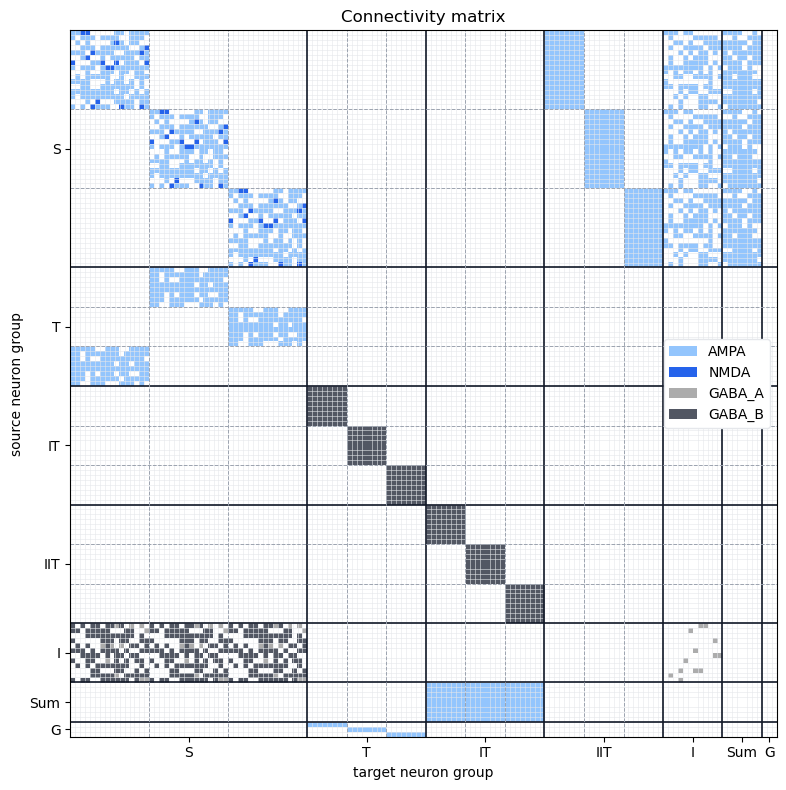

In [ ]:
plt.clf()
plt.close('all')

fig, ax = plt.subplots(figsize=(8, 8))


# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
syn_colors = {
    "GABA_B": "#525763",
    "GABA_A": "#acacac",
    "none":   "#ffffff",
    "AMPA":   "#93c5fd",
    "NMDA":   "#2563eb",
}

values = [-2, -1, 0, 1, 2]

colors = [
    syn_colors["GABA_B"],
    syn_colors["GABA_A"],
    syn_colors["none"],
    syn_colors["AMPA"],
    syn_colors["NMDA"],
]

cmap = ListedColormap(colors)

bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm   = BoundaryNorm(bounds, cmap.N)

im = ax.imshow(
    C,
    cmap          = cmap,
    norm          = norm,
    interpolation = 'none',
    aspect        = 'equal'
)


# ------------------------------------------------------------
# CELL GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_tot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_tot + 1) - 0.5, minor=True)

ax.grid(
    which     = 'minor',
    color     = '#e5e7eb',
    linestyle = '-',
    linewidth = 0.4
)

ax.tick_params(which='minor', bottom=False, left=False)


# ------------------------------------------------------------
# GROUP BOUNDARIES
# ------------------------------------------------------------
group_specs = [
    ("S",   NS * NE),
    ("T",   NS * NT),
    ("IT",  NS * NIT),
    ("IIT", NS * NIIT),
    ("I",   NI),
    ("Sum", NSum),
    ("G", NS),
]

group_sizes  = [size for _, size in group_specs]
group_labels = [name for name, _ in group_specs]

boundaries = np.cumsum(group_sizes)

boundary_color = "#111827"

for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color=boundary_color, linewidth=1.2)
    ax.axvline(b - 0.5, color=boundary_color, linewidth=1.2)


# ------------------------------------------------------------
# OPTIONAL: INTERNAL SUBPOPULATION BOUNDARIES
# ------------------------------------------------------------
sub_boundary_color = "#9ca3af"

start = 0

for name, size in group_specs:

    if name == "S":
        pop_size = NE
        n_pop    = NS
    elif name == "T":
        pop_size = NT
        n_pop    = NS
    elif name == "IT":
        pop_size = NIT
        n_pop    = NS
    elif name == "IIT":
        pop_size = NIIT
        n_pop    = NS
    else:
        start += size
        continue

    for p in range(1, int(n_pop)):
        b = start + p * pop_size

        ax.axhline(b - 0.5, color=sub_boundary_color, linewidth=0.7, linestyle='--')
        ax.axvline(b - 0.5, color=sub_boundary_color, linewidth=0.7, linestyle='--')

    start += size


# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------
centers = np.cumsum(group_sizes) - np.array(group_sizes) / 2 - 0.5

ax.set_xticks(centers)
ax.set_yticks(centers)

ax.set_xticklabels(group_labels)
ax.set_yticklabels(group_labels)

ax.set_xlabel("target neuron group")
ax.set_ylabel("source neuron group")
ax.set_title("Connectivity matrix")


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor=syn_colors["AMPA"],   edgecolor='none', label='AMPA'),
    Patch(facecolor=syn_colors["NMDA"],   edgecolor='none', label='NMDA'),
    Patch(facecolor=syn_colors["GABA_A"], edgecolor='none', label='GABA_A'),
    Patch(facecolor=syn_colors["GABA_B"], edgecolor='none', label='GABA_B'),
]

ax.legend(
    handles    = legend_elements,
    loc        = 'center right',
    frameon    = True,
    framealpha = 1.0,
    edgecolor  = '#e5e7eb'
)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

# set_params(model, param_group=param_group0) # TODO

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------

monitored_neurons = (
    E_ids
    + T_ids
    + IT_ids
    + IIT_ids
    + I_ids
    + Sum_ids
)


New configuration applied to DYNAP-SE1!


In [ ]:

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.15
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < sim_time)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, sim_time, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < sim_time

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


### **Plot Stimulation Rates**

### **Run Simulation**

In [ ]:
# Run Simulation

graph, filter_node, sink_node = ut.create_neuron_select_graph(
    model,
    monitored_neurons
)

graph.start()

# clear buffer
sink_node.get_events()
api.reset_timestamp()

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, input_firing_rate)

time.sleep(sim_time)
poisson_gen.stop()
graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
81604 events recorded.


### **Post Simulation Processing**

In [ ]:
# ------------------------------------------------------------
# EXTRACT EVENTS AND MAP TRUE ID -> DISPLAY ID
# ------------------------------------------------------------
spike_id = []
spike_t  = []

for evt in events:

    true_id = (evt.chip_id, evt.core_id, evt.neuron_id)

    disp_id = true_to_disp_idx[true_id]

    spike_id.append(disp_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id = np.array(spike_id)
spike_t  = np.array(spike_t)

In [ ]:
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def split_population(spike_id, spike_t, start_id, n_pops, pop_size):
    pop_spike_id = []
    pop_spike_t  = []

    for n in range(int(n_pops)):
        lo = start_id + n * pop_size
        hi = lo + pop_size - 1
        print(lo, "->", hi)

        mask = (spike_id >= lo) & (spike_id < hi)

        pop_spike_id.append(spike_id[mask])
        pop_spike_t.append(spike_t[mask])

    return pop_spike_id, pop_spike_t

In [ ]:
# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION GROUP
# ------------------------------------------------------------
S_spike_id, S_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = 0,
    n_pops   = NS,
    pop_size = NE
)

T_spike_id, T_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_id[0],
    n_pops   = NS,
    pop_size = NT
)

IT_spike_id, IT_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_id[1],
    n_pops   = NS,
    pop_size = NIT
)

IIT_spike_id, IIT_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_id[2],
    n_pops   = NS,
    pop_size = NIIT
)


I_spike_id, I_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_id[3],
    n_pops   = 1,
    pop_size = NI
)

Sum_spike_id, Sum_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_id[4],
    n_pops   = 1,
    pop_size = NSum
)


0 -> 15
16 -> 31
32 -> 47
48 -> 55
56 -> 63
64 -> 71
72 -> 79
80 -> 87
88 -> 95
96 -> 103
104 -> 111
112 -> 119
120 -> 131
132 -> 139


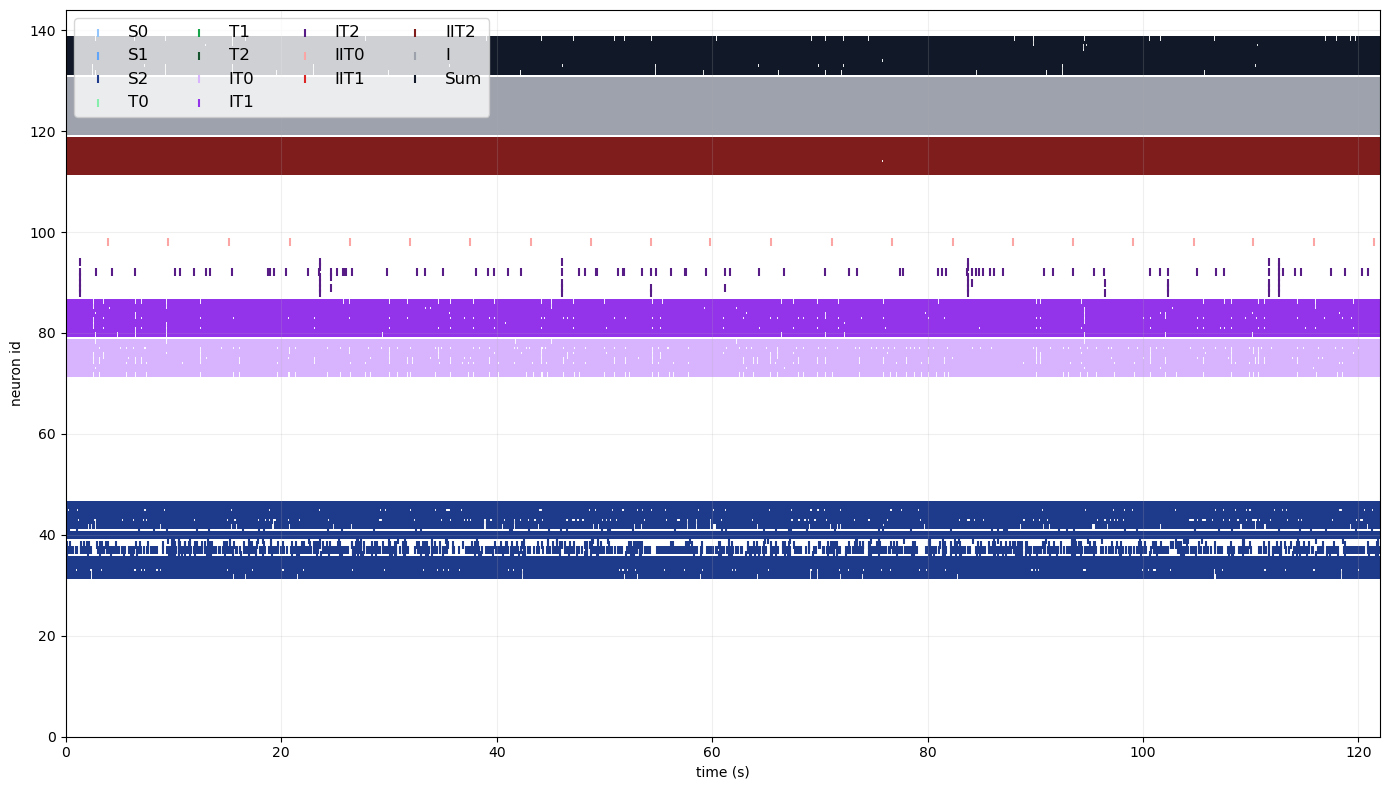

In [ ]:
# ------------------------------------------------------------
# PLOT RASTER
# ------------------------------------------------------------
plt.figure(figsize=(14, 8))

for s in range(int(NS)):
    plt.scatter(
        S_spike_t[s],
        S_spike_id[s],
        marker = '|',
        s      = 30,
        color  = get_color(colors_S, s),
        label  = f'S{s}'
    )

for t in range(int(NS)):
    plt.scatter(
        T_spike_t[t],
        T_spike_id[t],
        marker = '|',
        s      = 30,
        color  = get_color(colors_T, t),
        label  = f'T{t}'
    )

for i in range(int(NS)):
    plt.scatter(
        IT_spike_t[i],
        IT_spike_id[i],
        marker = '|',
        s      = 30,
        color  = get_color(colors_IT, i),
        label  = f'IT{i}'
    )

for i in range(int(NS)):
    plt.scatter(
        IIT_spike_t[i],
        IIT_spike_id[i],
        marker = '|',
        s      = 30,
        color  = get_color(colors_IIT, i),
        label  = f'IIT{i}'
    )

plt.scatter(
    I_spike_t,
    I_spike_id,
    marker = '|',
    s      = 30,
    color  = color_I,
    label  = 'I'
)

plt.scatter(
    Sum_spike_t,
    Sum_spike_id,
    marker = '|',
    s      = 30,
    color  = color_Sum,
    label  = 'Sum'
)

plt.xlabel("time (s)")
plt.ylabel("neuron id")
plt.legend(ncol=4, fontsize=12, loc="upper left")
plt.grid(True, alpha=0.2)
plt.xlim(0, sim_time+ 2)
plt.ylim(0, N_tot+1)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------
def fill_activity_gaps(rate, x, t_start, t_end, dt):

    rate = np.asarray(rate)
    x    = np.asarray(x)

    full_x    = np.arange(t_start, t_end + dt, dt)
    full_rate = np.zeros_like(full_x, dtype=float)

    if len(rate) == 0:
        return full_rate, full_x

    for rate_val, x_val in zip(rate, x):

        idx = int(np.round((x_val - t_start) / dt))

        if 0 <= idx < len(full_rate):
            full_rate[idx] = rate_val

    return full_rate, full_x

# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------
def compute_group_activity(spike_t_group, n_neurons, t_start, t_end, dt):

    activity_rate = []
    activity_x    = []

    for spike_times in spike_t_group:

        rate, x = population_activity(spike_times, n_neurons)

        rate, x = fill_activity_gaps(
            rate    = rate,
            x       = x,
            t_start = t_start,
            t_end   = t_end,
            dt      = dt
        )

        activity_rate.append(rate)
        activity_x.append(x)

    return activity_rate, activity_x

# ------------------------------------------------------------
# COMPUTE POPULATION ACTIVITY
# ------------------------------------------------------------

t_start = 0
t_end   = sim_time

S_activity_rate,   S_activity_x   = compute_group_activity(S_spike_t,   NE,   t_start, t_end, activity_dt_s)
T_activity_rate,   T_activity_x   = compute_group_activity(T_spike_t,   NT,   t_start, t_end, activity_dt_s)
IT_activity_rate,  IT_activity_x  = compute_group_activity(IT_spike_t,  NIT,  t_start, t_end, activity_dt_s)
IIT_activity_rate, IIT_activity_x = compute_group_activity(IIT_spike_t, NIIT, t_start, t_end, activity_dt_s)


I_activity_rate, I_activity_x = population_activity(I_spike_t, NI)
I_activity_rate, I_activity_x = fill_activity_gaps(
    rate    = I_activity_rate,
    x       = I_activity_x,
    t_start = t_start,
    t_end   = t_end,
    dt      = activity_dt_s
)


Sum_activity_rate, Sum_activity_x = population_activity(Sum_spike_t, NSum)
Sum_activity_rate, Sum_activity_x = fill_activity_gaps(
    rate    = Sum_activity_rate,
    x       = Sum_activity_x,
    t_start = t_start,
    t_end   = t_end,
    dt      = activity_dt_s
)


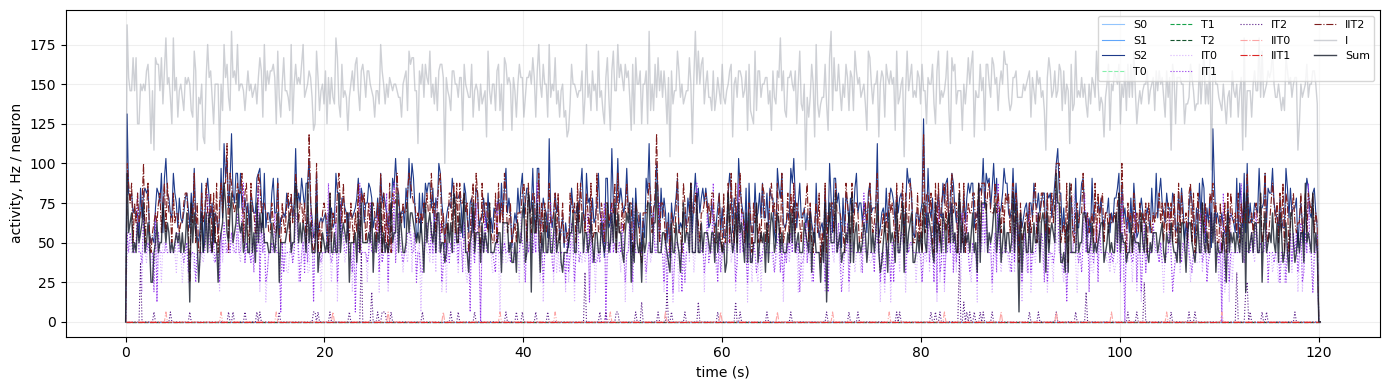

In [ ]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))

for s in range(int(NS)):
    ax.plot(
        S_activity_x[s],
        S_activity_rate[s],
        linewidth = 0.8,
        color     = get_color(colors_S, s),
        label     = f"S{s}"
    )

for t in range(int(NS)):
    ax.plot(
        T_activity_x[t],
        T_activity_rate[t],
        linewidth = 0.8,
        linestyle = "--",
        color     = get_color(colors_T, t),
        label     = f"T{t}"
    )

for i in range(int(NS)):
    ax.plot(
        IT_activity_x[i],
        IT_activity_rate[i],
        linewidth = 0.8,
        linestyle = ":",
        color     = get_color(colors_IT, i),
        label     = f"IT{i}"
    )

for i in range(int(NS)):
    ax.plot(
        IIT_activity_x[i],
        IIT_activity_rate[i],
        linewidth = 0.8,
        linestyle = "-.",
        color     = get_color(colors_IIT, i),
        label     = f"IIT{i}"
    )

ax.plot(
    I_activity_x,
    I_activity_rate,
    linewidth = 1.0,
    color     = color_I,
    alpha     = 0.5,
    label     = "I"
)

ax.plot(
    Sum_activity_x,
    Sum_activity_rate,
    linewidth = 1.0,
    color     = color_Sum,
    alpha     = 0.8,
    label     = "Sum"
)

ax.set_xlabel("time (s)")
ax.set_ylabel("activity, Hz / neuron")
ax.grid(True, alpha=0.2)
ax.legend(ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

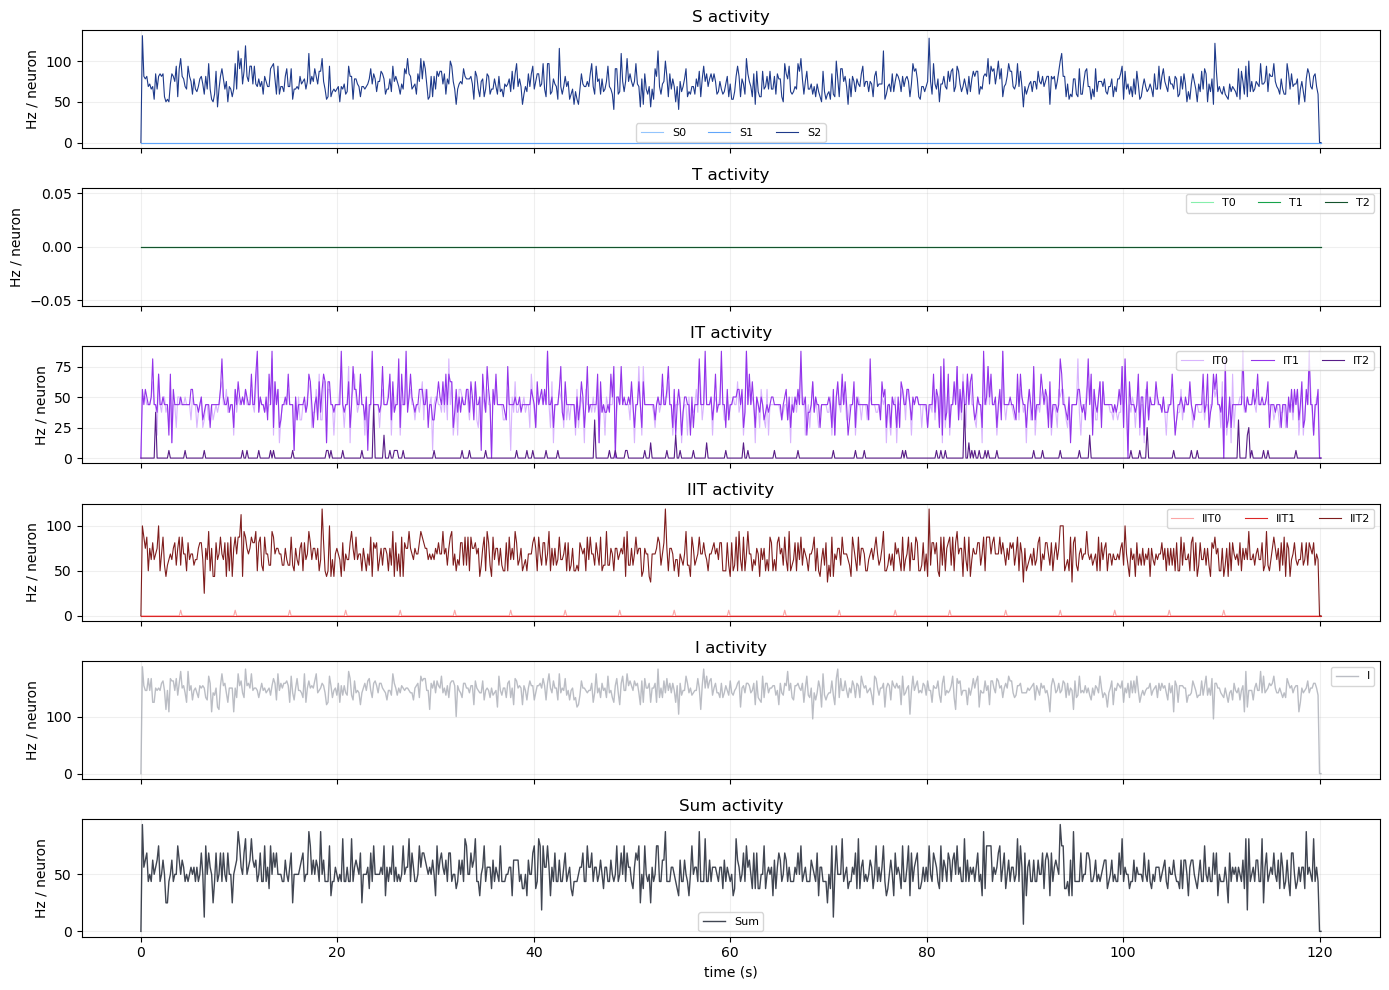

In [ ]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY IN STACKED SUBPLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(
    6, 1,
    figsize=(14, 10),
    sharex=True
)

pop_data = [
    ("S",   S_activity_x,   S_activity_rate,   NS, colors_S,   "-"),
    ("T",   T_activity_x,   T_activity_rate,   NS, colors_T,   "-"),
    ("IT",  IT_activity_x,  IT_activity_rate,  NS, colors_IT,  "-"),
    ("IIT", IIT_activity_x, IIT_activity_rate, NS, colors_IIT, "-"),
]

for ax, (name, x_list, rate_list, n_pop, colors, linestyle) in zip(axes[:4], pop_data):

    for i in range(int(n_pop)):
        ax.plot(
            x_list[i],
            rate_list[i],
            linewidth = 0.8,
            linestyle = linestyle,
            color     = get_color(colors, i),
            label     = f"{name}{i}"
        )

    ax.set_ylabel("Hz / neuron")
    ax.set_title(f"{name} activity")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=4, fontsize=8)


axes[4].plot(
    I_activity_x,
    I_activity_rate,
    linewidth = 1.0,
    color     = color_I,
    alpha     = 0.7,
    label     = "I"
)

axes[4].set_title("I activity")
axes[4].set_ylabel("Hz / neuron")
axes[4].grid(True, alpha=0.2)
axes[4].legend(fontsize=8)


axes[5].plot(
    Sum_activity_x,
    Sum_activity_rate,
    linewidth = 1.0,
    color     = color_Sum,
    alpha     = 0.8,
    label     = "Sum"
)

axes[5].set_title("Sum activity")
axes[5].set_ylabel("Hz / neuron")
axes[5].set_xlabel("time (s)")
axes[5].grid(True, alpha=0.2)
axes[5].legend(fontsize=8)

plt.tight_layout()
plt.show()

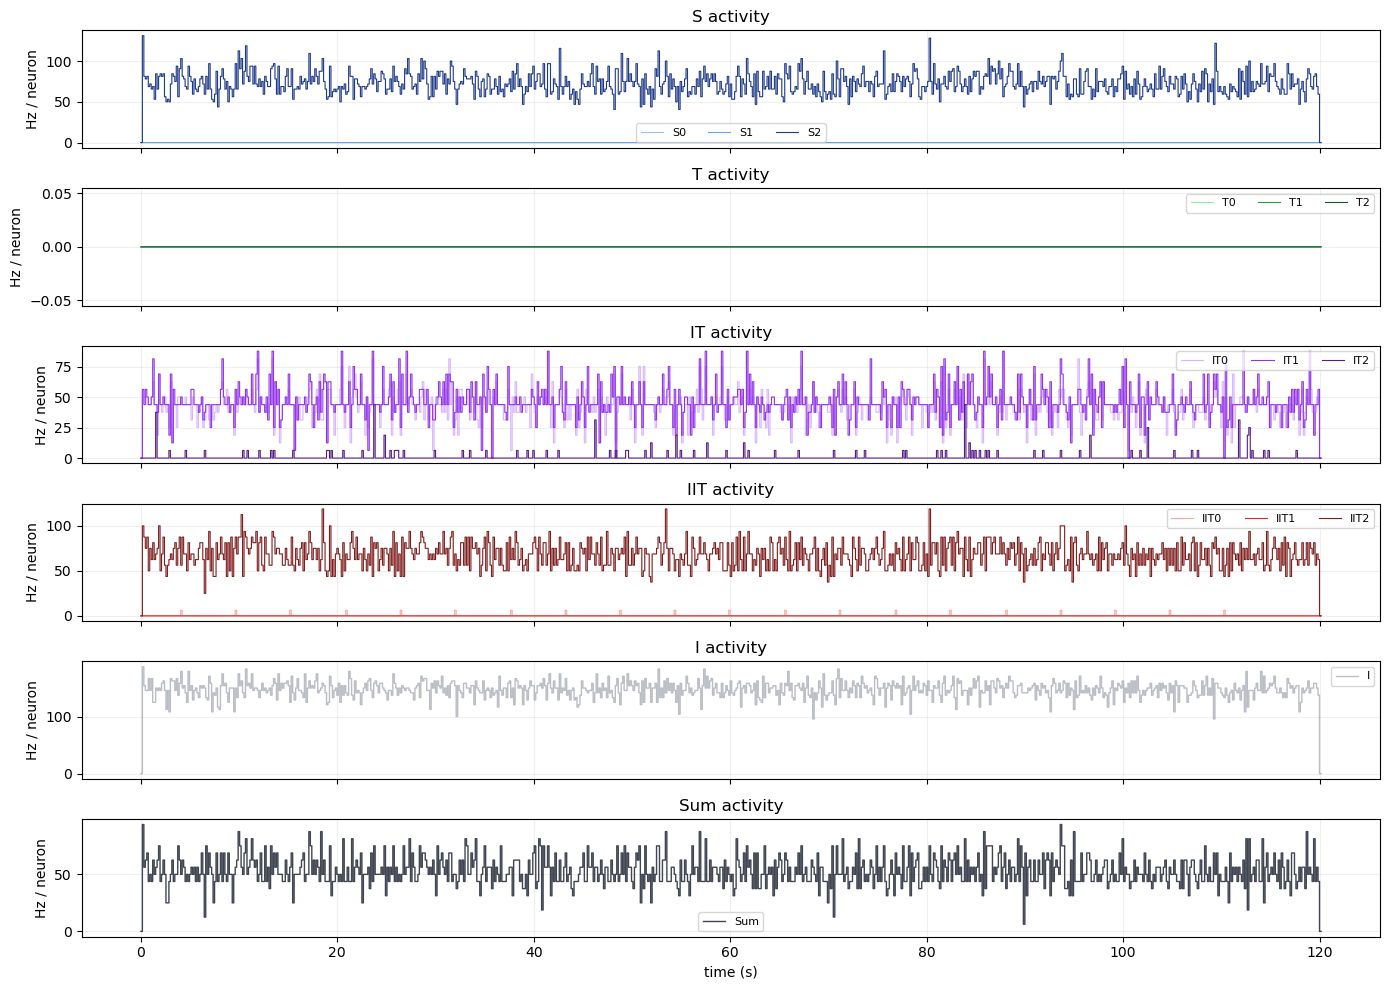

In [ ]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY IN STACKED SUBPLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(
    6, 1,
    figsize = (14, 10),
    sharex  = True
)

pop_data = [
    ("S",   S_activity_x,   S_activity_rate,   NS, colors_S,   "-"),
    ("T",   T_activity_x,   T_activity_rate,   NS, colors_T,   "-"),
    ("IT",  IT_activity_x,  IT_activity_rate,  NS, colors_IT,  "-"),
    ("IIT", IIT_activity_x, IIT_activity_rate, NS, colors_IIT, "-"),
]

for ax, (name, x_list, rate_list, n_pop, colors, linestyle) in zip(axes[:4], pop_data):

    for i in range(int(n_pop)):
        ax.step(
            x_list[i],
            rate_list[i],
            where     = "post",
            linewidth = 0.8,
            linestyle = linestyle,
            color     = get_color(colors, i),
            label     = f"{name}{i}"
        )

    ax.set_ylabel("Hz / neuron")
    ax.set_title(f"{name} activity")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=4, fontsize=8)


axes[4].step(
    I_activity_x,
    I_activity_rate,
    where     = "post",
    linewidth = 1.0,
    color     = color_I,
    alpha     = 0.7,
    label     = "I"
)

axes[4].set_title("I activity")
axes[4].set_ylabel("Hz / neuron")
axes[4].grid(True, alpha=0.2)
axes[4].legend(fontsize=8)


axes[5].step(
    Sum_activity_x,
    Sum_activity_rate,
    where     = "post",
    linewidth = 1.0,
    color     = color_Sum,
    alpha     = 0.8,
    label     = "Sum"
)

axes[5].set_title("Sum activity")
axes[5].set_ylabel("Hz / neuron")
axes[5].set_xlabel("time (s)")
axes[5].grid(True, alpha=0.2)
axes[5].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
input_spike_t  = np.asarray(spike_times)
input_spike_id = np.asarray(indices)

# ------------------------------------------------------------
# COMPUTE INPUT GENERATOR ACTIVITY
# ------------------------------------------------------------
G_activity_rate = []
G_activity_x    = []
G_ids           = np.unique(input_spike_id)

for gid in G_ids:
    mask = input_spike_id == gid
    rate, x = population_activity(input_spike_t[mask], n_neurons=10)

    G_activity_rate.append(rate)
    G_activity_x.append(x)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(16, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 2.5]}
)

# ------------------------------------------------------------
# RASTER
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    mask = input_spike_id == gid

    ax1.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s=30,
        color=colors_T[k],
        label=f'G{gid}'
    )

ax1.set_ylabel('spike generator id')
ax1.set_title('Poisson Spiketrain to FPGA')

ax1.set_yticks(G_ids)
ax1.set_yticklabels([str(int(gid)) for gid in G_ids])

ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------------------------------------------------
# INSTANTANEOUS ACTIVITY
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    ax2.plot(
        G_activity_x[k],
        G_activity_rate[k],
        linestyle='-',
        color=colors_T[k],
        label=f'G{gid}'
    )

ax2.set_xlabel('time, s')
ax2.set_ylabel('activity, Hz / generator')
ax2.set_xlim(0, t_tot)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

NameError: name 'spike_times' is not defined

In [ ]:
# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------


def get_activity(S_rates, S_times, t, pre_shift ,post_shift):

    post_shift_delta = 1
    
    S_rates = np.asarray(S_rates)
    S_times = np.asarray(S_times)

    pre_mask = (
        (S_times >= t - pre_shift) &
        (S_times <  t)
    )

    post_mask = (
        (S_times >= t + post_shift_delta) &
        (S_times <  t + post_shift)
    )

    A_pre = np.mean(S_rates[pre_mask])
    A_post = np.mean(S_rates[post_mask])

    return A_pre, A_post

def get_all_state_activities(S_activity_rate, S_activity_x, t, pre_shift = 0.5 ,post_shift = 1.5):

    A_pre  = []
    A_post = []

    for state in range(len(S_activity_rate)):

        pre, post = get_activity(S_activity_rate[state], S_activity_x[state], t, pre_shift, post_shift)

        A_pre.append(pre)
        A_post.append(post)

    return np.asarray(A_pre), np.asarray(A_post)

In [ ]:
# ------------------------------------------------------------
# CHECK TRANSITIONS
# ------------------------------------------------------------
correct_transitions    = 0
correct_suppression    = 0
wrong_transitions      = 0

shift       = 1.5
pre_shift   = 0.5
post_shift  = 1.5

for time_t, transition in transitions.items():          # transition = T_i

    if transition == "none":
        continue
    
    time_t = time_t + shift
    print("time", time_t)

    source_state = transition                           # state S_i activates T_i
    target_state = (transition + 1) % 3                 # T_i transitions to S_i-1

    print("source:", source_state, "-> target:", target_state)
    
    A_pre, A_post = get_all_state_activities(S_activity_rate, S_activity_x, time_t, pre_shift, post_shift)

    
    pre_winner  = np.argmax(A_pre)
    post_winner = np.argmax(A_post)

    print("pre_win:", pre_winner, " post_win:", post_winner)

    if source_state == pre_winner:
        if post_winner == target_state:
            correct_transitions += 1
            print("corr.")
        elif post_winner != target_state:
            wrong_transitions += 1
            print("--------WRONG TRANSITION---------")            

    if source_state != pre_winner:
        if post_winner == pre_winner:
            correct_suppression += 1
            print("corr. supr.")
        elif post_winner == target_state:
            wrong_transitions += 1
            print("--------WRONG TRANSITION---------")            


time 5.5
source: 1 -> target: 2
pre_win: 2  post_win: 2
corr. supr.
time 9.5
source: 2 -> target: 0
pre_win: 2  post_win: 0
corr.
time 13.5
source: 0 -> target: 1
pre_win: 0  post_win: 1
corr.
time 22.5
source: 1 -> target: 2
pre_win: 1  post_win: 2
corr.
time 29.5
source: 2 -> target: 0
pre_win: 2  post_win: 0
corr.
time 32.5
source: 0 -> target: 1
pre_win: 0  post_win: 1
corr.
time 37.5
source: 1 -> target: 2
pre_win: 1  post_win: 2
corr.
time 41.5
source: 2 -> target: 0
pre_win: 2  post_win: 0
corr.
time 46.5
source: 0 -> target: 1
pre_win: 0  post_win: 1
corr.
time 58.5
source: 1 -> target: 2
pre_win: 1  post_win: 2
corr.
time 66.5
source: 2 -> target: 0
pre_win: 2  post_win: 0
corr.
time 72.5
source: 0 -> target: 1
pre_win: 0  post_win: 1
corr.
time 76.5
source: 1 -> target: 2
pre_win: 1  post_win: 2
corr.
time 84.5
source: 2 -> target: 0
pre_win: 2  post_win: 0
corr.
time 88.5
source: 0 -> target: 1
pre_win: 0  post_win: 1
corr.
time 100.5
source: 1 -> target: 2
pre_win: 1  post_

In [ ]:
print(f"Correct transitions:    {correct_transitions}")
print(f"correct suppression: {correct_suppression}")
print(f"Wrong transitions:      {wrong_transitions}")

Correct transitions:    19
correct suppression: 1
Wrong transitions:      0


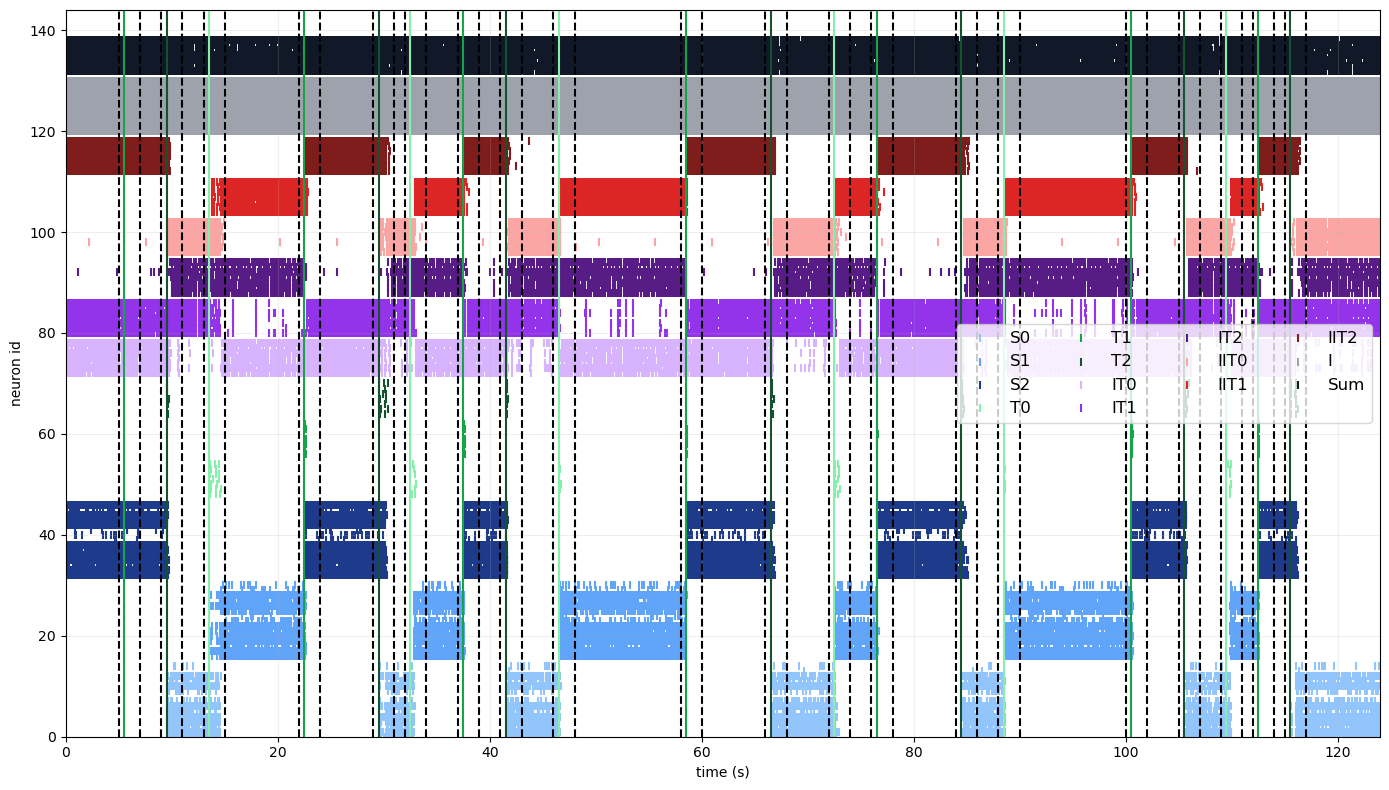

In [ ]:
# ------------------------------------------------------------
# PLOT RASTER
# ------------------------------------------------------------

dt_check = 1

    
plt.figure(figsize=(14, 8))

for time_t, transition in transitions.items():          # transition = T_i
    
    if transition == "none":
        continue

    plt.axvline(time_t - pre_shift + shift, linestyle = "--", color = "black")
    plt.axvline(time_t + shift, color = colors_T[transition])
    plt.axvline(time_t + post_shift + shift, linestyle = "--", color = "black")

for s in range(int(NS)):
    plt.scatter(
        S_spike_t[s],
        S_spike_id[s],
        marker = '|',
        s      = 30,
        color  = get_color(colors_S, s),
        label  = f'S{s}'
    )

for t in range(int(NS)):
    plt.scatter(
        T_spike_t[t],
        T_spike_id[t],
        marker = '|',
        s      = 30,
        color  = get_color(colors_T, t),
        label  = f'T{t}'
    )

for i in range(int(NS)):
    plt.scatter(
        IT_spike_t[i],
        IT_spike_id[i],
        marker = '|',
        s      = 30,
        color  = get_color(colors_IT, i),
        label  = f'IT{i}'
    )

for i in range(int(NS)):
    plt.scatter(
        IIT_spike_t[i],
        IIT_spike_id[i],
        marker = '|',
        s      = 30,
        color  = get_color(colors_IIT, i),
        label  = f'IIT{i}'
    )

plt.scatter(
    I_spike_t,
    I_spike_id,
    marker = '|',
    s      = 30,
    color  = color_I,
    label  = 'I'
)

plt.scatter(
    Sum_spike_t,
    Sum_spike_id,
    marker = '|',
    s      = 30,
    color  = color_Sum,
    label  = 'Sum'
)

plt.xlabel("time (s)")
plt.ylabel("neuron id")
plt.legend(ncol=4, fontsize=12)
plt.grid(True, alpha=0.2)
plt.xlim(0, t_tot+ 2)
plt.ylim(0, N_tot+1)

plt.tight_layout()
plt.show()